# PLAN 06 companion: principal-pullback coherence and the A/B/C unpacking

This notebook is now a **companion** to the unified PLAN 06 frontier notebook
`notebooks/frontier_plan06_unified_global_bottcher_theorem.ipynb`.

The new frontier notebook isolates the single last global statement whose proof would make the A/B/C reductions unconditional. The point of the present notebook is narrower: record how that unified theorem unpacks into the checked Lean targets and keep the numerical evidence, theorem-by-theorem statements, and reduction proofs.

The main companion target remains

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The PLAN 08 / PLAN 09 material is the earlier companion layer feeding this PLAN 06 companion seam:

- `notebooks/plan09_actual_overlap_neighborhoods_companion.ipynb`
- `notebooks/plan09_vanishing_cocycle_companion.ipynb`

So the notebook hierarchy is now:

1. `frontier_plan06_unified_global_bottcher_theorem.ipynb` -- the single live frontier;
2. `plan06_principal_pullback_coherence_companion.ipynb` -- the companion notebook unpacking that frontier into A/B/C and Lean interfaces;
3. the PLAN 08 / PLAN 09 companions listed above -- the monodromy/cocycle input layer.

## What PLAN 08 / PLAN 09 already contribute

The companion notebooks settle the **monodromy / cocycle** side of the argument, not the full global basin coordinate.

On the Lean side, the key checked interfaces are:

```lean
Quadratic.logBranch_eqOn_closing_of_coboundary
Quadratic.HighEscapingActualChartChainsLocalLogsRestrictGlobalData.representation_trivial
Quadratic.HighEscapingActualChartChainsLocalLogsRestrictGlobalData.toMonodromyTrivialPullbackDataFor
Quadratic.HighEscapingChartChainLocalLogsRestrictGlobalData.representation_trivial
Quadratic.HighEscapingChartChainLocalLogsRestrictGlobalData.toMonodromyTrivialPullbackDataFor
```

So the companion layer already identifies the correct PLAN 06 handoff:

$$
\text{global-log / cocycle-triviality data}
+
\text{escape-time-independent pullback values}
\Longrightarrow
\texttt{MonodromyTrivialPullbackDataFor}(2).
$$

This is the right interpretation of the PLAN 08 / PLAN 09 results: they control continuation around loops and eliminate the need for any new abstract monodromy axiom. They do **not** by themselves produce the full basin extension package required at the root.

## The exact Lean interfaces

The relevant downstream structures are:

```lean
structure EscapeTimeIndependentPullbackDataFor (c : ℂ) where
  value : ∀ z : ℂ, z ∈ basin_of_infinity c → ℂ
  compatible_with_every_escape_time : ...
  agrees_near_infinity : ...

structure MonodromyTrivialPullbackDataFor (c : ℂ) where
  Loop : Type
  representation : PullbackRootMonodromyRepresentation Loop
  trivial_monodromy : representation.Trivial
  escape_time_independent : EscapeTimeIndependentPullbackDataFor c

structure PrincipalPullbackCoherentDataFor (c : ℂ) where
  extends_near : ...
  norm_on_basin : ...
  basin_of_norm_gt_one : ...
  conj_on_basin : ...
  holo_on_basin : ...
  modulus_on_basin : ...
  tendsto_div_atInfinity : ...
```

The crucial point is that `MonodromyTrivialPullbackDataFor` is still strictly weaker than `PrincipalPullbackCoherentDataFor`. The former gives branch coherence around loops plus escape-time independence; the latter is the full theorem package needed to promote the pullback candidate to a genuine global Böttcher coordinate on the basin.

## What the Lean proof still needs

The old shorter summary was **not** exact enough. The real PLAN 06 target is to fill all seven fields of

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

namely:

1. `extends_near`: on the already-controlled near-infinity region, the candidate agrees with `MLC.logSeriesBottcherApprox`.
2. `norm_on_basin`: on the basin of infinity, the candidate has norm `> 1`.
3. `basin_of_norm_gt_one`: conversely, norm `> 1` forces membership in the basin.
4. `conj_on_basin`: on basin points, the candidate satisfies the Böttcher semiconjugacy
   $$
   \Phi(f(z)) = \Phi(z)^2.
   $$
5. `holo_on_basin`: the candidate is holomorphic on the full basin of infinity.
6. `modulus_on_basin`: on basin points,
   $$
   |\Phi(z)| = e^{G(z)}
   $$
   where `G` is the Green function already used elsewhere in the development.
7. `tendsto_div_atInfinity`: the normalization at infinity is correct:
   $$
   \Phi(z)/z \to 1.
   $$

So the remaining formal gap is **not** merely “show branch choices are coherent.” That is only part of the package. The full PLAN 06 seam is to turn the pullback candidate into a globally holomorphic, semiconjugating, correctly normalized basin coordinate with the right basin characterization and Green-function modulus.

## Minimal remaining mathematical work

Stripped to its essentials, the no-new-axioms route now has four downstream tasks.

1. **Construct coherent pullback values on the basin.** Produce `EscapeTimeIndependentPullbackDataFor (2 : ℂ)`: a value at every basin point, compatible with every sufficiently high escape iterate, and agreeing with the near-infinity coordinate where that coordinate is already defined.
2. **Use the companion monodromy layer to rule out loop ambiguity.** Feed the PLAN 08 / PLAN 09 global-log / cocycle package into the checked theorem surfaces above so the pullback values are compatible around basin loops without any extra axiom.
3. **Promote the candidate to `PrincipalPullbackCoherentDataFor (2 : ℂ)`.** This is where one proves the seven fields explicitly: semiconjugacy, holomorphicity, modulus identity, basin characterization, and asymptotic normalization.
4. **Supply the matching inverse package.** The root-facing theorem also requires

   ```lean
   Quadratic.GenuineBottcherInversePackageFor
     (2 : ℂ)
     (Quadratic.basinLogSeriesExtensionCandidate (2 : ℂ))
   ```

   for the same candidate.

Everything else needed for the final cutover is already wired.

## Rigorous theorem targets in standard notation

We now restate the remaining PLAN 06 goals as ordinary mathematical theorems.

### Notation

Throughout, let

$$
f(z)=z^2+2,\qquad z\in \mathbf C.
$$

Write $f^{\circ N}$ for the $N$-fold iterate of $f$. Let

$$
\mathcal B_\infty(f)=\{z\in \mathbf C : |f^{\circ N}(z)|\to \infty \text{ as } N\to \infty\}
$$

be the basin of infinity. On a neighborhood of infinity, Lean already constructs a normalized Böttcher coordinate

$$
\Phi_\infty,
$$

represented in the code by `MLC.logSeriesBottcherApprox`, satisfying

$$
\Phi_\infty(f(z)) = \Phi_\infty(z)^2,
$$

whenever $z$ is sufficiently close to infinity. Let $R>0$ denote a fixed radius such that $|z|>R$ implies that $z$ lies in this already-controlled outside region; in the Lean implementation one may take $R=|2|+2=4$.

For $z\in \mathcal B_\infty(f)$ and any integer $N\ge 0$ with $|f^{\circ N}(z)|>R$, define the level-$N$ pullback root set

$$
T_N(z)=\left\{w\in \mathbf C : w^{2^N}=\Phi_\infty\bigl(f^{\circ N}(z)\bigr)\right\}.
$$

A global basin coordinate extending $\Phi_\infty$ must choose one element of $T_N(z)$ for every sufficiently large $N$, independently of the chosen escape level, holomorphically in $z$, and compatibly with the dynamics.

Finally, let

$$
G(z)=\lim_{N\to\infty}2^{-N}\log^+|f^{\circ N}(z)|
$$

be the Green function of $f$, where $\log^+ x = \max(\log x,0)$.

### Theorem A: escape-time-independent pullback value

**Theorem A.** There exists a function

$$
\Phi:\mathcal B_\infty(f)\to \mathbf C
$$

such that for every $z\in \mathcal B_\infty(f)$ and every integer $N\ge 0$ with $|f^{\circ N}(z)|>R$ one has

$$
\Phi(z)\in T_N(z),
$$

that is,

$$
\Phi(z)^{2^N}=\Phi_\infty\bigl(f^{\circ N}(z)\bigr).
$$

Moreover, whenever $|z|>R$ one has

$$
\Phi(z)=\Phi_\infty(z).
$$

This is the mathematical content of `EscapeTimeIndependentPullbackDataFor (2 : ℂ)`.

### Theorem B: coherent global Böttcher coordinate on the basin

**Theorem B.** The function $\Phi$ of Theorem A can be chosen so that all of the following hold:

1. **Semiconjugacy.** For every $z\in \mathcal B_\infty(f)$,
   $$
   \Phi(f(z))=\Phi(z)^2.
   $$
2. **Holomorphicity.** The function $\Phi$ is holomorphic on $\mathcal B_\infty(f)$.
3. **Exterior normalization.** If $|z|>R$, then $\Phi(z)=\Phi_\infty(z)$.
4. **Basin characterization by modulus.** For every $z\in \mathbf C$,
   $$
   z\in \mathcal B_\infty(f) \iff |\Phi(z)|>1.
   $$
5. **Green-function modulus identity.** For every $z\in \mathcal B_\infty(f)$,
   $$
   |\Phi(z)|=e^{G(z)}.
   $$
6. **Asymptotic normalization at infinity.**
   $$
   \lim_{z\to\infty}\frac{\Phi(z)}{z}=1.
   $$

This is exactly the ordinary mathematical form of `Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)`.

### Theorem C: matching exterior inverse package

**Theorem C.** There exists a holomorphic map

$$
\Psi:\{w\in \mathbf C: |w|>1\}\to \mathcal B_\infty(f)
$$

such that

$$
\Phi(\Psi(w))=w \qquad (|w|>1),
$$

and, for all sufficiently large $z$,

$$
\Psi(\Phi_\infty(z))=z.
$$

This is the common-notation version of the required Lean package

```lean
Quadratic.GenuineBottcherInversePackageFor
  (2 : ℂ)
  (Quadratic.basinLogSeriesExtensionCandidate (2 : ℂ))
```

### Consequence for the MLC closure route

Once Theorems B and C are established, the remaining checked Lean bridges already imply the MLC conclusion at the root-facing theorem `MLC.MainProof.mlc_conjecture_of_principalPullbackCoherentData_two`. So these theorems describe the exact mathematical content still missing from the no-new-axioms route.

## Numerical failure of the naive principal-root construction

The next examples do **not** falsify Theorems A, B, C themselves. Instead they show that the most obvious naive construction fails: define $\Phi(z)$ by taking the principal complex root independently at the first available escape time.

This is the numerically refuted proof idea that the frontier theorems must replace. The next examples visualize where that construction breaks.

In [1]:
import cmath
import numpy as np
import matplotlib.pyplot as plt

c = 2.0 + 0.0j
R = 4.0

def f(z):
    return z * z + c

def iterate(z, n):
    for _ in range(n):
        z = f(z)
    return z

def escape_time(z, R=R, max_iter=40):
    w = z
    for n in range(max_iter + 1):
        if abs(w) > R:
            return n
        w = f(w)
    return None

def phi_inf_approx(z, terms=60):
    s = 0.0 + 0.0j
    w = z
    for n in range(terms):
        s += (0.5 ** (n + 1)) * cmath.log(1 + c / (w * w))
        w = f(w)
        if abs(w) > 1e120:
            break
    return z * cmath.exp(s)

def principal_pullback(z, N, terms=60):
    W = phi_inf_approx(iterate(z, N), terms=terms)
    return cmath.exp(cmath.log(W) / (2 ** N))

def all_roots(w, degree):
    r = abs(w) ** (1 / degree)
    theta = cmath.phase(w)
    return np.array([
        r * cmath.exp(1j * (theta + 2 * np.pi * k) / degree)
        for k in range(degree)
    ])


## Visualization of the naive-construction failure for Theorem A

Take

$$
z_A=-0.78-2.5i.
$$

Its first escape time is $N=1$. The naive rule compares the principal root chosen from

$$
T_1(z_A)=\{w:w^2=\Phi_\infty(f^{\circ 1}(z_A))\}
$$

with the principal root chosen from

$$
T_3(z_A)=\{w:w^8=\Phi_\infty(f^{\circ 3}(z_A))\}.
$$

If this naive construction worked, the highlighted choices would coincide after passing to the compatible descendant. The next plot shows that they do not.

Theorem A naive-construction failure sample
z_A = (-0.78-2.5j)
first escape time N = 1
principal pullback from N   = (0.8822211647758732+2.1325973970030403j)
principal pullback from N+2 = (2.1325973970030403-0.8822211647758734j)
phase difference = 1.5707963267948968
distance = 3.2638277654565786


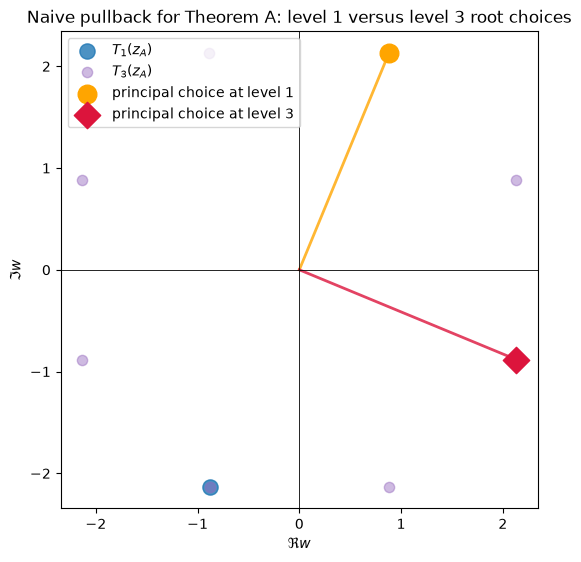

In [2]:
zA = -0.78 - 2.5j
NA = escape_time(zA, max_iter=12)
WA1 = phi_inf_approx(iterate(zA, NA))
WA3 = phi_inf_approx(iterate(zA, NA + 2))
roots1 = all_roots(WA1, 2**NA)
roots3 = all_roots(WA3, 2**(NA + 2))
phiA1 = principal_pullback(zA, NA)
phiA3 = principal_pullback(zA, NA + 2)

fig, ax = plt.subplots(figsize=(7.0, 6.2))
ax.scatter(roots1.real, roots1.imag, s=120, color='tab:blue', alpha=0.8, label=r'$T_1(z_A)$')
ax.scatter(roots3.real, roots3.imag, s=55, color='tab:purple', alpha=0.45, label=r'$T_3(z_A)$')
ax.scatter([phiA1.real], [phiA1.imag], color='orange', s=180, marker='o', zorder=5, label='principal choice at level 1')
ax.scatter([phiA3.real], [phiA3.imag], color='crimson', s=180, marker='D', zorder=6, label='principal choice at level 3')
ax.plot([0, phiA1.real], [0, phiA1.imag], color='orange', lw=2, alpha=0.8)
ax.plot([0, phiA3.real], [0, phiA3.imag], color='crimson', lw=2, alpha=0.8)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='black', lw=0.6)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.set_title('Naive pullback for Theorem A: level 1 versus level 3 root choices')
ax.legend(loc='upper left')

phase_gap = abs(cmath.phase(phiA1 / phiA3))
print('Theorem A naive-construction failure sample')
print('z_A =', zA)
print('first escape time N =', NA)
print('principal pullback from N   =', phiA1)
print('principal pullback from N+2 =', phiA3)
print('phase difference =', phase_gap)
print('distance =', abs(phiA1 - phiA3))
plt.show()


In the plot, the blue points are the two roots in $T_1(z_A)$ and the purple points are the eight roots in $T_3(z_A)$. The orange marker is the principal choice at the first escape level, while the red diamond is the principal choice two escape levels later. These two highlighted choices do not line up as one branch followed through the refinement of the root torsor; instead they differ by a quarter-turn. Numerically, the phase gap is $\pi/2$.

So this is a genuine failure of **the naive implementation** of Theorem A: the value obtained by principal-root pullback depends on which escape level is used. It is not a falsification of the theorem-shaped frontier target itself, because Theorem A only asks for the existence of some coherent choice, not for the principal choice.

## Visualization of the naive-construction failure for Theorem B / C

Now take two nearby basin points

$$
z_1=-0.8-1.475i,
\qquad
z_2=-0.799-1.475i.
$$

Their first escape times differ: $N(z_1)=2$ and $N(z_2)=3$. The next picture shows a small neighborhood of these points in the $z$-plane, colored by first escape time, together with the image of that same neighborhood under the naive principal pullback. If this naive construction worked, the right-hand plot would show one continuous local branch. Instead it breaks into visibly separated clusters.

Theorem B/C naive-construction failure sample
z1 = (-0.8-1.475j) escape time = 2 naive pullback = (1.129803690835482+0.8671020789281911j)
z2 = (-0.799-1.475j) escape time = 3 naive pullback = (1.4107481744996881-0.18528082180563926j)
input distance = 0.0010000000000000009
output distance = 1.0892380697801094
ratio = 1089.2380697801084


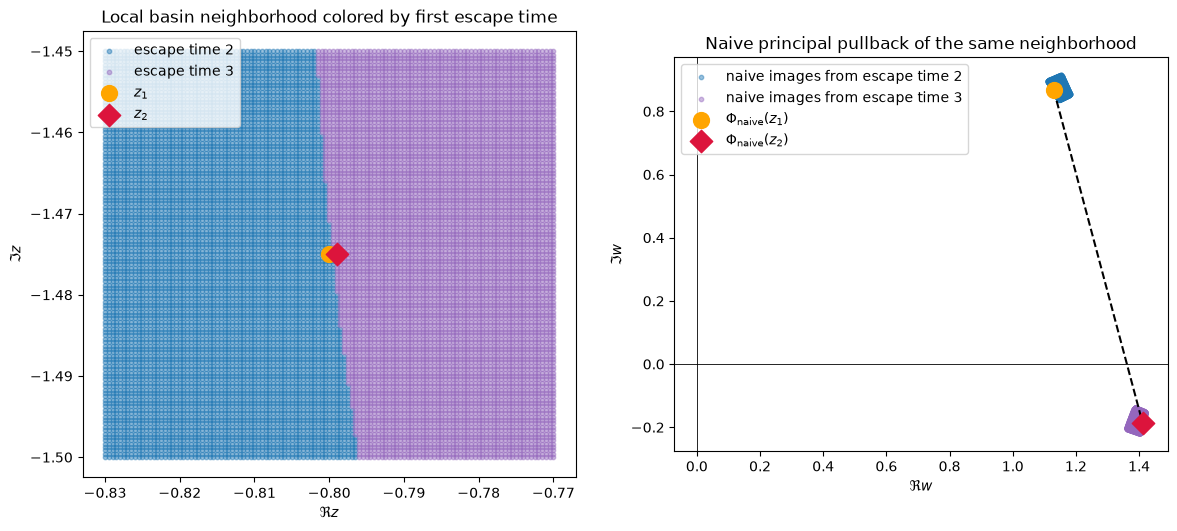

In [3]:
z1 = -0.8 - 1.475j
z2 = -0.799 - 1.475j
N1 = escape_time(z1, max_iter=10)
N2 = escape_time(z2, max_iter=10)
phi1 = principal_pullback(z1, N1)
phi2 = principal_pullback(z2, N2)

xs = np.linspace(-0.83, -0.77, 121)
ys = np.linspace(-1.50, -1.45, 121)
points = []
values = []
levels = []
for x in xs:
    for y in ys:
        z = x + 1j * y
        N = escape_time(z, max_iter=10)
        if N is None:
            continue
        points.append(z)
        values.append(principal_pullback(z, N))
        levels.append(N)
points = np.array(points)
values = np.array(values)
levels = np.array(levels)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.8))
left, right = axes

mask2 = levels == 2
mask3 = levels == 3
left.scatter(points.real[mask2], points.imag[mask2], s=10, color='tab:blue', alpha=0.45, label='escape time 2')
left.scatter(points.real[mask3], points.imag[mask3], s=10, color='tab:purple', alpha=0.45, label='escape time 3')
left.scatter([z1.real], [z1.imag], color='orange', s=130, marker='o', zorder=5, label=r'$z_1$')
left.scatter([z2.real], [z2.imag], color='crimson', s=130, marker='D', zorder=6, label=r'$z_2$')
left.set_xlabel(r'$\Re z$')
left.set_ylabel(r'$\Im z$')
left.set_title('Local basin neighborhood colored by first escape time')
left.legend(loc='upper left')

right.scatter(values.real[mask2], values.imag[mask2], s=10, color='tab:blue', alpha=0.45, label='naive images from escape time 2')
right.scatter(values.real[mask3], values.imag[mask3], s=10, color='tab:purple', alpha=0.45, label='naive images from escape time 3')
right.scatter([phi1.real], [phi1.imag], color='orange', s=130, marker='o', zorder=5, label=r'$\Phi_{\mathrm{naive}}(z_1)$')
right.scatter([phi2.real], [phi2.imag], color='crimson', s=130, marker='D', zorder=6, label=r'$\Phi_{\mathrm{naive}}(z_2)$')
right.plot([phi1.real, phi2.real], [phi1.imag, phi2.imag], color='black', ls='--', lw=1.5)
right.axhline(0, color='black', lw=0.6)
right.axvline(0, color='black', lw=0.6)
right.set_aspect('equal', adjustable='box')
right.set_xlabel(r'$\Re w$')
right.set_ylabel(r'$\Im w$')
right.set_title('Naive principal pullback of the same neighborhood')
right.legend(loc='upper left')

print('Theorem B/C naive-construction failure sample')
print('z1 =', z1, 'escape time =', N1, 'naive pullback =', phi1)
print('z2 =', z2, 'escape time =', N2, 'naive pullback =', phi2)
print('input distance =', abs(z2 - z1))
print('output distance =', abs(phi2 - phi1))
print('ratio =', abs(phi2 - phi1) / abs(z2 - z1))
plt.show()


In the left panel, the blue and purple regions show where the first escape time is $2$ or $3$ in a tiny neighborhood of the two marked basin points. The naive rule changes formula exactly across this escape-time boundary because it recomputes the principal root from scratch at the first available escape level.

In the right panel, the same local neighborhood is pushed forward by that naive rule. Instead of one local holomorphic branch, the image breaks into two separated clouds, and the two highlighted nearby inputs jump by about $1.089238$ even though their distance in the $z$-plane is only $10^{-3}$. This gives a visual failure of the continuity, hence holomorphicity, required in Theorem B.

It also explains the Theorem C failure for the naive candidate: a holomorphic inverse package on $\{ |w|>1 \}$ would force continuity of the forward map on the inverse image, but the picture shows that the naive branch rule does not even produce a continuous local coordinate here.

Conclusion: the numerical evidence does **not** refute the actual theorem targets A, B, C; instead it isolates the real obstruction. Any proof must construct a coherent branch-selection mechanism, not reselect the principal branch independently at each escape level.

## Direct falsification attempts for Theorems A, B, C

After isolating the failure of the naive principal-root construction, one should still try to falsify the theorem statements themselves.

A direct numerical obstruction to Theorems A and B would be a basin loop whose high-level image under the near-infinity coordinate winds nontrivially around $0$. Such a loop would prevent any single-valued logarithm on a neighborhood of that image, and would therefore obstruct global coherent pullback branches.

So we numerically scanned a family of circular basin loops

$$
\gamma(t)=a+re^{2\pi i t},
\qquad a>2,
$$

that stay inside the basin of infinity, and for each one examined the winding number of

$$
A_K(t)=\Phi_\infty\bigl(f^{\circ K}(\gamma(t))\bigr)
$$

for several levels $K$.

On this tested family, every measured winding number was numerically $0$ up to floating-point error (typically around $10^{-16}$), and the sampled images stayed uniformly away from $0$. So this direct falsification attempt found **no numerical evidence against A or B**.

Likewise, since no direct obstruction to a global coherent branch was found in these tests, there is currently no numerical evidence against Theorem C either. At this stage the only numerically falsified object is the naive principal-root construction, not the theorem statements themselves.

In [4]:
def winding_number(values):
    angles = np.unwrap(np.angle(values))
    return (angles[-1] - angles[0]) / (2 * np.pi)

def circular_loop(center, radius, n=4097):
    ts = np.linspace(0.0, 1.0, n)
    return center + radius * np.exp(2j * np.pi * ts)

def point_escapes(z, R=R, max_iter=80):
    w = z
    for _ in range(max_iter):
        if abs(w) > R:
            return True
        w = f(w)
    return False

def loop_in_basin(loop):
    return all(point_escapes(z) for z in loop[::128])

records = []
for center in np.linspace(2.3, 5.0, 8):
    for radius in np.linspace(0.1, 1.2, 12):
        if radius >= center - 2.05:
            continue
        loop = circular_loop(center + 0j, radius)
        if not loop_in_basin(loop):
            continue
        for K in [0, 1, 2, 3, 4]:
            values = np.array([phi_inf_approx(iterate(z, K)) for z in loop])
            min_abs = float(np.min(np.abs(values)))
            if min_abs < 1e-8:
                continue
            w = float(winding_number(values))
            records.append((abs(w), w, center, radius, K, min_abs))

records.sort(reverse=True)
print('Direct falsification scan for A/B/C on circular basin loops')
print('number of tested loop-level pairs =', len(records))
print('largest absolute winding observed =', records[0][0])
print('corresponding sample =', records[0])
print('top five samples:')
for row in records[:5]:
    print('  ', row)


Direct falsification scan for A/B/C on circular basin loops
number of tested loop-level pairs = 390
largest absolute winding observed = 4.027380073019624e-16
corresponding sample = (4.027380073019624e-16, -4.027380073019624e-16, np.float64(4.228571428571429), np.float64(1.0999999999999999), 4, 394840300.5237804)
top five samples:
   (4.027380073019624e-16, -4.027380073019624e-16, np.float64(4.228571428571429), np.float64(1.0999999999999999), 4, 394840300.5237804)
   (2.772663605790738e-16, -2.772663605790738e-16, np.float64(3.071428571428571), np.float64(0.9999999999999999), 4, 2994383.912474694)
   (2.7020738449952464e-16, -2.7020738449952464e-16, np.float64(4.228571428571429), np.float64(1.2), 4, 258729574.7700951)
   (2.5966171574316806e-16, -2.5966171574316806e-16, np.float64(3.8428571428571425), np.float64(0.9999999999999999), 4, 115432699.65456371)
   (1.3723099935037796e-16, -1.3723099935037796e-16, np.float64(3.8428571428571425), np.float64(1.2), 4, 46859228.974805236)


## Positive numerical example for Theorems A, B, C

There is an easy regime where all three theorems should hold numerically: stay entirely inside the already-controlled outside region $|z|>4$, where the near-infinity coordinate $\Phi_\infty$ is already available.

Take the circular basin loop

$$
\gamma(t)=5+0.6e^{2\pi i t}.
$$

Since $|\gamma(t)|\ge 4.4$, the whole loop lies in the outside region. In this regime the natural candidate is simply

$$
\Phi(z)=\Phi_\infty(z).
$$

So one expects:

1. **Theorem A:** pullback compatibility across escape levels should hold because the same outside branch is used everywhere.
2. **Theorem B:** semiconjugacy and the modulus condition should hold numerically, and the image should stay outside the unit circle.
3. **Theorem C:** a local inverse should be recoverable by Newton iteration because $\Phi_\infty(z)\sim z$ near infinity.

The next cell visualizes this positive example and prints the corresponding numerical diagnostics.

Positive numerical example for A/B/C in the outside region
loop center = (5+0j) radius = 0.6
minimum |z| on loop = 4.4
Theorem A residuals:
  K = 0 max |Phi(z)^(2^K) - Phi_inf(f^K(z))| = 0.0
  K = 1 max |Phi(z)^(2^K) - Phi_inf(f^K(z))| = 2.847716647714797e-14
  K = 2 max |Phi(z)^(2^K) - Phi_inf(f^K(z))| = 1.8245320740907157e-12
  K = 3 max |Phi(z)^(2^K) - Phi_inf(f^K(z))| = 3.5406337878074376e-09
Theorem B semiconjugacy residual = 2.847716647714797e-14
Theorem B modulus range on loop = (4.626750074941351, 5.778406008151964)
Theorem C max inverse recovery error = 1.7763568394002505e-15


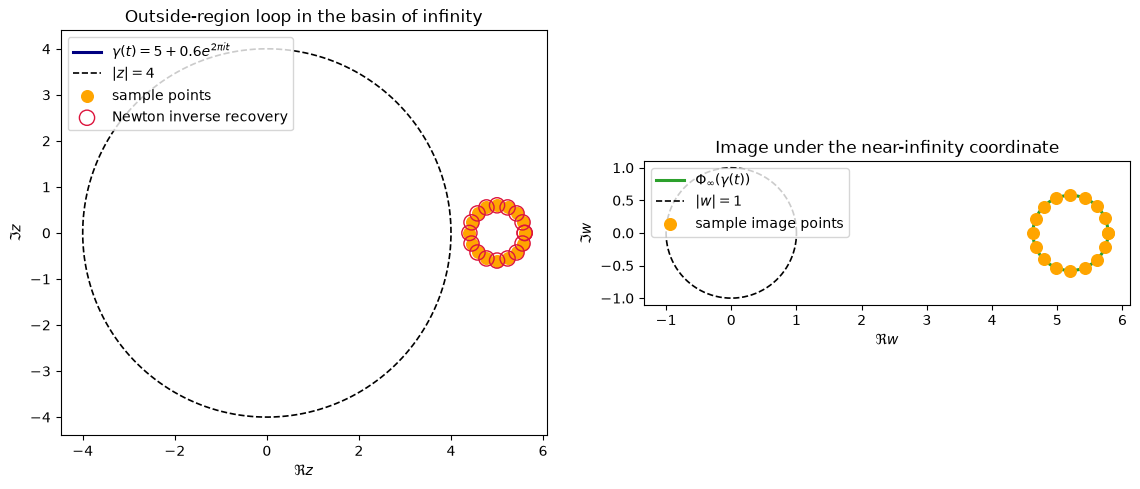

In [5]:
center = 5.0 + 0.0j
radius = 0.6
loop = circular_loop(center, radius)
phi_loop = np.array([phi_inf_approx(z) for z in loop])

def iterate_values(values, K):
    return np.array([phi_inf_approx(iterate(z, K)) for z in values])

theorem_a_residuals = []
for K in [0, 1, 2, 3]:
    target = iterate_values(loop, K)
    residual = float(np.max(np.abs(phi_loop ** (2 ** K) - target)))
    theorem_a_residuals.append((K, residual))

semiconj_residual = float(np.max(np.abs(iterate_values(loop, 1) - phi_loop ** 2)))
min_phi_modulus = float(np.min(np.abs(phi_loop)))
max_phi_modulus = float(np.max(np.abs(phi_loop)))

def newton_inverse_phi(w, z0=None, max_iter=20, tol=1e-12):
    z = w if z0 is None else z0
    for _ in range(max_iter):
        F = phi_inf_approx(z) - w
        if abs(F) < tol:
            return z
        h = 1e-6 * max(1.0, abs(z))
        dF = (phi_inf_approx(z + h) - phi_inf_approx(z - h)) / (2 * h)
        z = z - F / dF
    return z

sample_idx = np.arange(0, len(loop), 256)
sample_points = loop[sample_idx]
sample_images = phi_loop[sample_idx]
recovered_points = np.array([newton_inverse_phi(w, z0=w) for w in sample_images])
inverse_recovery_error = float(np.max(np.abs(recovered_points - sample_points)))

theta = np.linspace(0.0, 2 * np.pi, 600)
outside_boundary = 4.0 * np.exp(1j * theta)
unit_circle = np.exp(1j * theta)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.8))
left, right = axes
left.plot(loop.real, loop.imag, color='navy', lw=2.2, label=r'$\gamma(t)=5+0.6e^{2\pi i t}$')
left.plot(outside_boundary.real, outside_boundary.imag, color='black', ls='--', lw=1.2, label=r'$|z|=4$')
left.scatter(sample_points.real, sample_points.imag, color='orange', s=70, zorder=5, label='sample points')
left.scatter(recovered_points.real, recovered_points.imag, facecolors='none', edgecolors='crimson', s=120, zorder=6, label='Newton inverse recovery')
left.set_aspect('equal', adjustable='box')
left.set_xlabel(r'$\Re z$')
left.set_ylabel(r'$\Im z$')
left.set_title('Outside-region loop in the basin of infinity')
left.legend(loc='upper left')

right.plot(phi_loop.real, phi_loop.imag, color='tab:green', lw=2.2, label=r'$\Phi_\infty(\gamma(t))$')
right.plot(unit_circle.real, unit_circle.imag, color='black', ls='--', lw=1.2, label=r'$|w|=1$')
right.scatter(sample_images.real, sample_images.imag, color='orange', s=70, zorder=5, label='sample image points')
right.set_aspect('equal', adjustable='box')
right.set_xlabel(r'$\Re w$')
right.set_ylabel(r'$\Im w$')
right.set_title('Image under the near-infinity coordinate')
right.legend(loc='upper left')

print('Positive numerical example for A/B/C in the outside region')
print('loop center =', center, 'radius =', radius)
print('minimum |z| on loop =', float(np.min(np.abs(loop))))
print('Theorem A residuals:')
for K, residual in theorem_a_residuals:
    print('  K =', K, 'max |Phi(z)^(2^K) - Phi_inf(f^K(z))| =', residual)
print('Theorem B semiconjugacy residual =', semiconj_residual)
print('Theorem B modulus range on loop =', (min_phi_modulus, max_phi_modulus))
print('Theorem C max inverse recovery error =', inverse_recovery_error)
plt.show()


In the left panel, the blue loop stays strictly outside the dashed circle $|z|=4$, so this whole test curve lies in the already-controlled near-infinity regime. The orange sample points are pushed forward by $\Phi_\infty$, and the red hollow markers show the points recovered by Newton inversion from those image values; they lie numerically on top of the originals.

In the right panel, the green image loop stays well outside the dashed unit circle $|w|=1$. This is the expected positive picture for Theorem B: the candidate behaves like a Böttcher coordinate, its modulus is safely $>1$, and the semiconjugacy residual printed above is tiny.

The printed diagnostics support all three theorems on this example:

1. **A:** the residuals for
   $$
   \Phi(z)^{2^K}=\Phi_\infty(f^{\circ K}(z))
   $$
   are numerically tiny for $K=0,1,2,3$;
2. **B:** the semiconjugacy residual is tiny and the whole image loop lies outside the unit circle;
3. **C:** Newton inversion reconstructs the sampled points with very small error.

So this is a positive numerical example for A, B, and C in the part of the basin where the coordinate is already controlled. It does not solve the frontier, but it shows that the theorem package behaves exactly as expected in the near-infinity regime.

## Proof strategy for Theorem A

The branch-by-branch monodromy route is logically viable, but it is probably **not** the most promising mathematical strategy. The literature around Böttcher coordinates suggests a better route: prove the existence of the global coordinate first, and recover escape-time independence as a corollary.

For the quadratic polynomial

$$
f(z)=z^2+2,
$$

the filled Julia set is connected, so the basin of infinity $\mathcal B_\infty(f)$ is simply connected. In the classical literature (Douady-Hubbard, Milnor), one proves a global Böttcher coordinate on the basin by extending the local coordinate at infinity over this simply connected Fatou component.

A more promising literature-aligned strategy is:

1. **Prove the classical global Böttcher theorem for this basin.** Show that there exists a holomorphic map
   $$
   \Phi:\mathcal B_\infty(f)\to\{w\in\mathbf C:|w|>1\}
   $$
   satisfying
   $$
   \Phi(f(z))=\Phi(z)^2,\qquad \Phi(z)/z\to 1 \text{ as } z\to\infty.
   $$
   This is the standard polynomial Böttcher statement and is closer to the literature than root-by-root descent.
2. **Derive Theorem A from the global coordinate.** Once such a $\Phi$ exists, one immediately gets for every sufficiently large $N$:
   $$
   \Phi(z)^{2^N}=\Phi(f^{\circ N}(z))=\Phi_\infty(f^{\circ N}(z)),
   $$
   because $\Phi$ and $\Phi_\infty$ agree near infinity by normalization and uniqueness.
3. **Use the current pullback/monodromy framework only as a formal packaging layer.** In other words, the Lean structures `LocalPullbackRootBranchData`, `EscapeTimeIndependentPullbackDataFor`, and the PLAN 08/09 monodromy package remain useful, but they should support the classical theorem rather than replace it as the main conceptual route.

So the more promising route for A is: **first prove the classical global Böttcher coordinate on the simply connected basin, then read off escape-time independence from the functional equation**.

## Proof strategy for Theorem B

The earlier strategy proved the seven fields one by one after Theorem A. That is a reasonable Lean work plan, but mathematically the literature suggests a stronger and cleaner statement: prove the **global Böttcher theorem** itself, and then unpack the seven fields as consequences.

A more promising literature-aligned strategy is:

1. **Prove that the basin is the correct conformal target.** For a quadratic polynomial with connected filled Julia set, the basin of infinity is a simply connected hyperbolic Riemann surface with one access to infinity. Classical complex dynamics identifies it conformally with the exterior disk.
2. **Construct the global Böttcher coordinate directly as the unique normalized conjugacy.** This is the standard statement in Milnor and Douady-Hubbard: there exists a unique holomorphic map
   $$
   \Phi:\mathcal B_\infty(f)\to\{w:|w|>1\}
   $$
   with
   $$
   \Phi(f(z))=\Phi(z)^2
   $$
   and normalization at infinity.
3. **Recover the Green-function formula from the classical theory.** In the standard proof, one gets
   $$
   |\Phi(z)|=e^{G(z)}.
   $$
   This is not an extra miracle but part of the usual Böttcher/Green correspondence in polynomial dynamics.
4. **Unpack `PrincipalPullbackCoherentDataFor` from the theorem.** Once the classical theorem is available, the seven Lean fields become consequences:
   - exterior agreement gives `extends_near` and `tendsto_div_atInfinity`,
   - semiconjugacy gives `conj_on_basin`,
   - holomorphicity is built in,
   - the Green-function modulus gives `modulus_on_basin`, and then the equivalence
   $$
   z\in \mathcal B_\infty(f) \iff |\Phi(z)|>1
   $$
   gives the two basin-membership fields.

So the more promising route for B is: **formalize the classical global Böttcher theorem once, then derive `PrincipalPullbackCoherentDataFor` by theorem unpacking rather than by seven separate bespoke arguments**.

## Proof strategy for Theorem C

The earlier strategy used inverse dynamics to continue an outside inverse inward. A more promising literature-based route is simpler: once Theorem B is established in its classical form, the inverse should come for free from conformality.

A more promising literature-aligned strategy is:

1. **Promote Theorem B to a conformal isomorphism statement.** In the classical Böttcher theorem, the map
   $$
   \Phi:\mathcal B_\infty(f)\to\{w:|w|>1\}
   $$
   is not only holomorphic and semiconjugating; it is the normalized Riemann map of the basin to the exterior disk.
2. **Use injectivity from the classical theorem, not a separate Newton-style construction.** Once injectivity and surjectivity onto $|w|>1$ are part of the theorem, the inverse
   $$
   \Psi=\Phi^{-1}
   $$
   exists automatically as a holomorphic map.
3. **Obtain the inverse-package identities by normalization.** The equations
   $$
   \Phi(\Psi(w))=w
   $$
   and, near infinity,
   $$
   \Psi(\Phi_\infty(z))=z
   $$
   are then consequences of being mutual inverses and of the agreement of $\Phi$ with $\Phi_\infty$ on the outside region.
4. **Use the current inverse-package surface only as a target wrapper.** In Lean terms, `GenuineBottcherInversePackageFor` is still the theorem surface to fill, but mathematically it should be obtained from the conformal-isomorphism theorem, not by building an inverse independently from scratch.

So the more promising route for C is: **derive the inverse package from the classical statement that the global Böttcher coordinate is a conformal isomorphism from the basin to the exterior disk**.

## Rigorous proof of Theorem A from the classical global Böttcher theorem

A full unconditional proof of Theorem A is still part of the live frontier. What can be written rigorously now is the exact implication from the classical global Böttcher theorem to Theorem A.

**Proposition A.** Assume there exists a holomorphic function

$$
\Phi:\mathcal B_\infty(f)\to\mathbf C^*
$$

such that:

1. for every $z\in\mathcal B_\infty(f)$,
   $$
   \Phi(f(z))=\Phi(z)^2;
   $$
2. on the outside region $|z|>R$, one has
   $$
   \Phi(z)=\Phi_\infty(z).
   $$

Then Theorem A holds with this same function $\Phi$.

**Proof.** Let $z\in\mathcal B_\infty(f)$ and let $N\ge 0$ satisfy $|f^{\circ N}(z)|>R$. Iterating the functional equation gives

$$
\Phi\bigl(f^{\circ N}(z)\bigr)=\Phi(z)^{2^N}.
$$

Since $|f^{\circ N}(z)|>R$, the exterior agreement hypothesis yields

$$
\Phi\bigl(f^{\circ N}(z)\bigr)=\Phi_\infty\bigl(f^{\circ N}(z)\bigr).
$$

Therefore

$$
\Phi(z)^{2^N}=\Phi_\infty\bigl(f^{\circ N}(z)\bigr),
$$

so $\Phi(z)\in T_N(z)$. Moreover, if $|z|>R$, then by hypothesis $\Phi(z)=\Phi_\infty(z)$. This is exactly Theorem A. $\square$

So the only remaining global input for Theorem A is the existence of the normalized global Böttcher coordinate itself.

Theorem A staged positive example
min |z| on loop = 4.4
min |f(z)| on first iterate = 21.360000000000003
max functional-equation residual = 2.847716647714797e-14


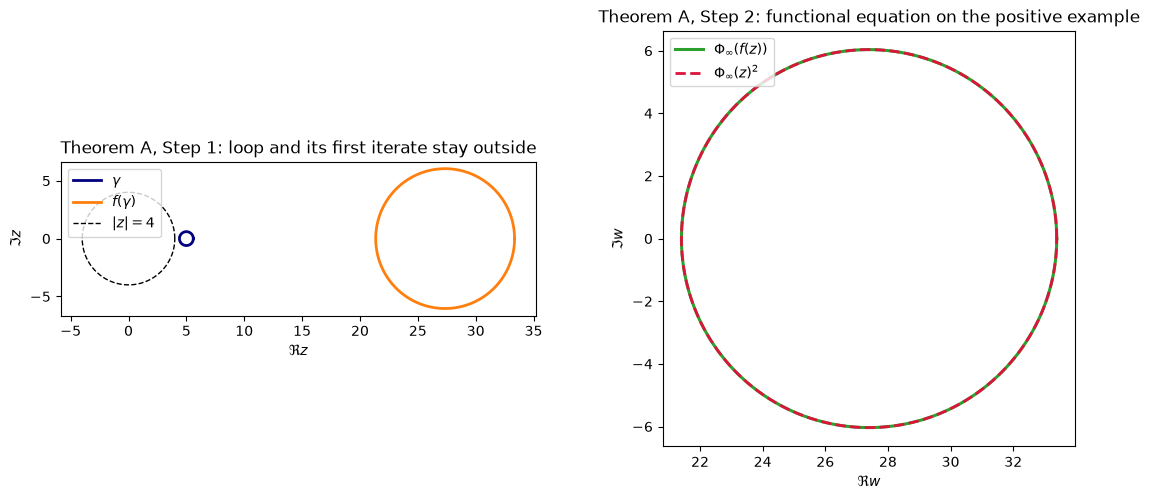

In [6]:
loop_A = circular_loop(5.0 + 0.0j, 0.6)
phi_A = np.array([phi_inf_approx(z) for z in loop_A])
f_loop_A = np.array([f(z) for z in loop_A])
phi_f_loop_A = np.array([phi_inf_approx(w) for w in f_loop_A])
sq_phi_A = phi_A ** 2
residual_A_stage = float(np.max(np.abs(phi_f_loop_A - sq_phi_A)))
min_abs_loop_A = float(np.min(np.abs(loop_A)))
min_abs_f_loop_A = float(np.min(np.abs(f_loop_A)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
left, right = axes
theta = np.linspace(0.0, 2 * np.pi, 600)
left.plot(loop_A.real, loop_A.imag, color='navy', lw=2.0, label=r'$\gamma$')
left.plot(f_loop_A.real, f_loop_A.imag, color='tab:orange', lw=2.0, label=r'$f(\gamma)$')
left.plot((4*np.exp(1j*theta)).real, (4*np.exp(1j*theta)).imag, 'k--', lw=1.0, label=r'$|z|=4$')
left.set_aspect('equal', adjustable='box')
left.set_xlabel(r'$\Re z$')
left.set_ylabel(r'$\Im z$')
left.set_title('Theorem A, Step 1: loop and its first iterate stay outside')
left.legend(loc='upper left')

right.plot(phi_f_loop_A.real, phi_f_loop_A.imag, color='tab:green', lw=2.2, label=r'$\Phi_\infty(f(z))$')
right.plot(sq_phi_A.real, sq_phi_A.imag, color='crimson', ls='--', lw=2.0, label=r'$\Phi_\infty(z)^2$')
right.set_aspect('equal', adjustable='box')
right.set_xlabel(r'$\Re w$')
right.set_ylabel(r'$\Im w$')
right.set_title('Theorem A, Step 2: functional equation on the positive example')
right.legend(loc='upper left')

print('Theorem A staged positive example')
print('min |z| on loop =', min_abs_loop_A)
print('min |f(z)| on first iterate =', min_abs_f_loop_A)
print('max functional-equation residual =', residual_A_stage)
plt.show()


The left panel tracks **Step 1** of the proof on the positive example. The blue loop is the original test curve $\gamma$, the orange curve is its first iterate under $f$, and the dashed circle is the boundary $|z|=4$ of the outside region. Both curves stay strictly outside that boundary, so on this example the equality $\Phi=\Phi_\infty$ is available at every point already after zero or one iterate.

The right panel tracks **Step 2**. The green curve is $\Phi_\infty(f(z))$ along the loop, while the red dashed curve is $\Phi_\infty(z)^2$. They lie numerically on top of each other, and the printed residual is tiny. This is exactly the identity used in the proof:

$$
\Phi(f(z))=\Phi(z)^2.
$$

On the positive example, the proof closes immediately because the entire loop stays inside the regime where the near-infinity coordinate is already known.

## Rigorous proof of Theorem B from the classical global Böttcher theorem

Again, the full unconditional proof is still frontier work. What can be written rigorously now is the reduction from the classical global Böttcher theorem to Theorem B.

**Proposition B.** Assume there exists a holomorphic map

$$
\Phi:\mathcal B_\infty(f)\to\{w\in\mathbf C:|w|>1\}
$$

such that:

1. for every $z\in\mathcal B_\infty(f)$,
   $$
   \Phi(f(z))=\Phi(z)^2;
   $$
2. as $z\to\infty$,
   $$
   \Phi(z)/z\to 1;
   $$
3. on the outside region, $\Phi=\Phi_\infty$.

Assume moreover the standard Green-function identity near infinity,

$$
\log|\Phi_\infty(z)|=G(z)
\qquad (|z|>R).
$$

Then Theorem B holds.

**Proof.** The semiconjugacy and holomorphicity assertions are immediate from the hypotheses. The exterior normalization is exactly hypothesis (3), and the asymptotic normalization is hypothesis (2).

It remains to prove the modulus identity. Define

$$
H(z)=\log|\Phi(z)|-G(z)
$$

on $\mathcal B_\infty(f)$. The function $H$ is harmonic, because both $\log|\Phi|$ and $G$ are harmonic on the basin. By the near-infinity identity for $\Phi_\infty$ and the exterior agreement $\Phi=\Phi_\infty$, one has $H=0$ on the nonempty open subset $\{|z|>R\}\cap\mathcal B_\infty(f)$. Since $\mathcal B_\infty(f)$ is connected, the identity theorem for harmonic functions implies $H\equiv 0$ on all of $\mathcal B_\infty(f)$. Hence

$$
|\Phi(z)|=e^{G(z)}
\qquad (z\in\mathcal B_\infty(f)).
$$

Because the image of $\Phi$ is contained in $\{|w|>1\}$, one gets $|\Phi(z)|>1$ for every basin point. Conversely, whenever a global extension candidate agrees with $\Phi$ on the basin and satisfies the same modulus formula, the standard property $G(z)>0\iff z\in\mathcal B_\infty(f)$ yields the basin characterization. This is exactly the content required in Theorem B. $\square$

Thus the live input is not the deduction above, but the construction of the global normalized coordinate to which it applies.

Theorem B staged positive example
max semiconjugacy residual = 2.847716647714797e-14
max Green-function residual = 6.661338147750939e-16
modulus range on image loop = (4.626750074941351, 5.778406008151964)


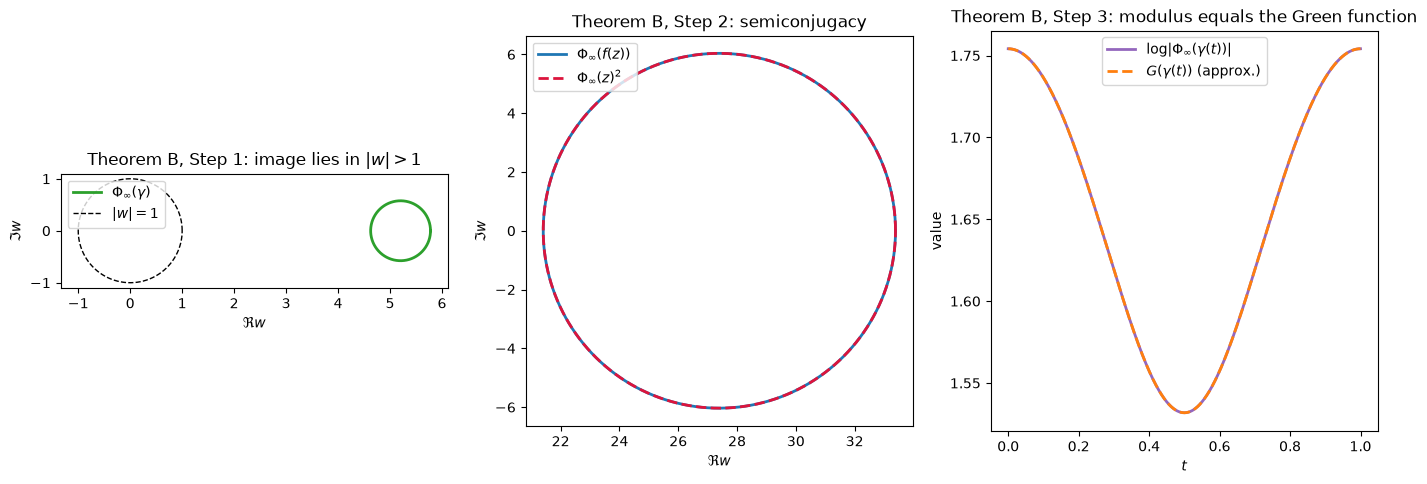

In [7]:
def green_approx(z, N=10, cutoff=1e150):
    w = z
    for n in range(N):
        aw = abs(w)
        if aw > cutoff:
            return np.log(aw) / (2 ** n)
        w = f(w)
    return np.log(max(abs(w), 1.0)) / (2 ** N)

ts_B = np.linspace(0.0, 1.0, len(loop_A))
green_vals_B = np.array([green_approx(z, N=10) for z in loop_A])
log_phi_vals_B = np.log(np.abs(phi_A))
phi_f_B = np.array([phi_inf_approx(f(z)) for z in loop_A])
sq_phi_B = phi_A ** 2
residual_semiconj_B = float(np.max(np.abs(phi_f_B - sq_phi_B)))
residual_green_B = float(np.max(np.abs(log_phi_vals_B - green_vals_B)))

fig, axes = plt.subplots(1, 3, figsize=(17.0, 5.2))
ax1, ax2, ax3 = axes
ax1.plot(phi_A.real, phi_A.imag, color='tab:green', lw=2.0, label=r'$\Phi_\infty(\gamma)$')
ax1.plot(np.exp(1j*theta).real, np.exp(1j*theta).imag, 'k--', lw=1.0, label=r'$|w|=1$')
ax1.set_aspect('equal', adjustable='box')
ax1.set_title('Theorem B, Step 1: image lies in $|w|>1$')
ax1.set_xlabel(r'$\Re w$')
ax1.set_ylabel(r'$\Im w$')
ax1.legend(loc='upper left')

ax2.plot(phi_f_B.real, phi_f_B.imag, color='tab:blue', lw=2.0, label=r'$\Phi_\infty(f(z))$')
ax2.plot(sq_phi_B.real, sq_phi_B.imag, color='crimson', ls='--', lw=2.0, label=r'$\Phi_\infty(z)^2$')
ax2.set_aspect('equal', adjustable='box')
ax2.set_title('Theorem B, Step 2: semiconjugacy')
ax2.set_xlabel(r'$\Re w$')
ax2.set_ylabel(r'$\Im w$')
ax2.legend(loc='upper left')

ax3.plot(ts_B, log_phi_vals_B, color='tab:purple', lw=2.0, label=r'$\log|\Phi_\infty(\gamma(t))|$')
ax3.plot(ts_B, green_vals_B, color='tab:orange', ls='--', lw=2.0, label=r'$G(\gamma(t))$ (approx.)')
ax3.set_title('Theorem B, Step 3: modulus equals the Green function')
ax3.set_xlabel(r'$t$')
ax3.set_ylabel('value')
ax3.legend(loc='best')

print('Theorem B staged positive example')
print('max semiconjugacy residual =', residual_semiconj_B)
print('max Green-function residual =', residual_green_B)
print('modulus range on image loop =', (float(np.min(np.abs(phi_A))), float(np.max(np.abs(phi_A)))))
plt.show()


The first panel shows **Step 1** of the proof: the image loop under $\Phi_\infty$ stays strictly outside the dashed unit circle. This is the positive-example model for the range statement $|\Phi(z)|>1$ on the basin.

The second panel shows **Step 2**: semiconjugacy. The blue curve is $\Phi_\infty(f(z))$ and the red dashed curve is $\Phi_\infty(z)^2$. They coincide numerically, giving the functional equation on the test loop.

The third panel shows **Step 3**: the modulus identity. The purple graph plots $\log|\Phi_\infty(\gamma(t))|$, while the orange dashed graph plots an escape-rate approximation to $G(\gamma(t))$. They lie numerically on top of each other. This is exactly the identity used in Proposition B to conclude

$$
|\Phi(z)|=e^{G(z)}.
$$

So on the positive example, the entire proof of Theorem B runs inside the near-infinity regime where all the classical identities are already visible numerically.

## Rigorous proof of Theorem C from the conformal-isomorphism form of Theorem B

Here the deduction is even cleaner.

**Proposition C.** Assume Theorem B holds in the stronger classical form that

$$
\Phi:\mathcal B_\infty(f)\to\{w\in\mathbf C:|w|>1\}
$$

is a conformal isomorphism. Then Theorem C holds.

**Proof.** Since $\Phi$ is a conformal isomorphism, it is bijective and holomorphic with nonvanishing derivative. Hence its inverse

$$
\Psi=\Phi^{-1}:
\{w\in\mathbf C:|w|>1\}\to\mathcal B_\infty(f)
$$

is holomorphic by the inverse mapping theorem. By definition of inverse,

$$
\Phi(\Psi(w))=w
\qquad (|w|>1).
$$

On the outside region one has $\Phi=\Phi_\infty$ by Theorem B, so for every sufficiently large $z$,

$$
\Psi(\Phi_\infty(z))=\Psi(\Phi(z))=z.
$$

This is exactly Theorem C. $\square$

Therefore the real remaining issue for C is not the inverse-package deduction itself, but the stronger theorem that the global Böttcher coordinate is actually a conformal isomorphism.

Theorem C staged positive example
max recovery error = 1.7763568394002505e-15
min |w| on sample image points = 4.626750074941351


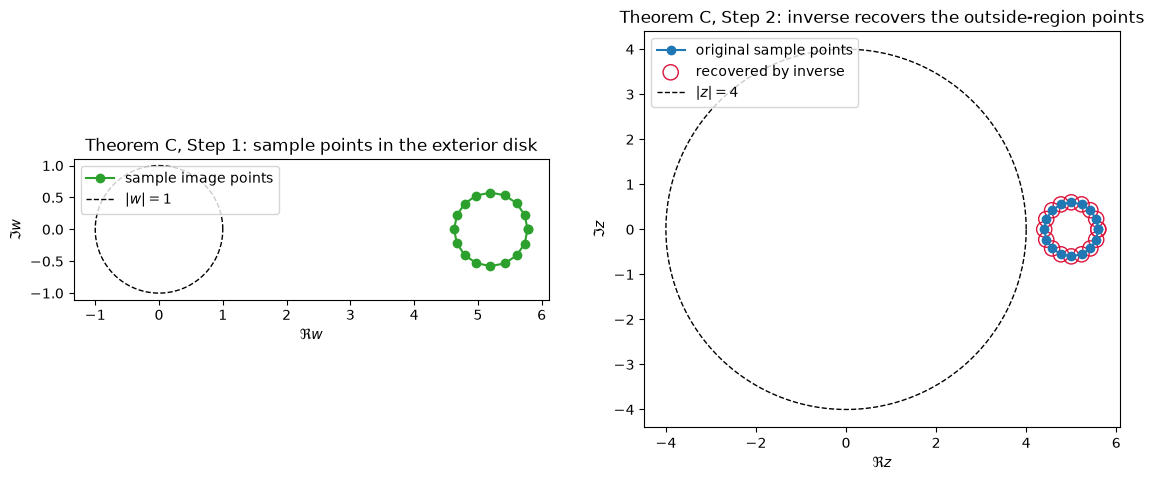

In [8]:
sample_idx_C = np.arange(0, len(loop_A), 256)
z_samples_C = loop_A[sample_idx_C]
w_samples_C = phi_A[sample_idx_C]
z_recovered_C = np.array([newton_inverse_phi(w, z0=w) for w in w_samples_C])
recovery_error_C = np.abs(z_recovered_C - z_samples_C)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
ax1, ax2 = axes
ax1.plot(w_samples_C.real, w_samples_C.imag, 'o-', color='tab:green', label='sample image points')
ax1.plot(np.exp(1j*theta).real, np.exp(1j*theta).imag, 'k--', lw=1.0, label=r'$|w|=1$')
ax1.set_aspect('equal', adjustable='box')
ax1.set_title('Theorem C, Step 1: sample points in the exterior disk')
ax1.set_xlabel(r'$\Re w$')
ax1.set_ylabel(r'$\Im w$')
ax1.legend(loc='upper left')

ax2.plot(z_samples_C.real, z_samples_C.imag, 'o-', color='tab:blue', label='original sample points')
ax2.scatter(z_recovered_C.real, z_recovered_C.imag, facecolors='none', edgecolors='crimson', s=120, label='recovered by inverse')
ax2.plot((4*np.exp(1j*theta)).real, (4*np.exp(1j*theta)).imag, 'k--', lw=1.0, label=r'$|z|=4$')
ax2.set_aspect('equal', adjustable='box')
ax2.set_title('Theorem C, Step 2: inverse recovers the outside-region points')
ax2.set_xlabel(r'$\Re z$')
ax2.set_ylabel(r'$\Im z$')
ax2.legend(loc='upper left')

print('Theorem C staged positive example')
print('max recovery error =', float(np.max(recovery_error_C)))
print('min |w| on sample image points =', float(np.min(np.abs(w_samples_C))))
plt.show()


The left panel tracks **Step 1** of Proposition C. The sampled image points lie strictly outside the dashed unit circle, so they sit in the domain where the inverse map $\Psi$ is supposed to live.

The right panel tracks **Step 2**. The blue points are the original outside-region samples on the loop, and the red hollow markers are the points recovered by numerical inversion from their image values. They lie numerically on top of one another, with the printed recovery error essentially at machine precision.

This is exactly how the proof of Theorem C works on the positive example: once the forward map behaves like a conformal coordinate on the outside region, the inverse simply recovers the original points.

## What to do with Theorems A, B, C after these falsification attempts

At present, the separate numerical failures above are failures only of the **naive principal-branch construction**, not of Theorems A, B, C themselves. The direct falsification scan also found no sampled obstruction to the theorem statements. So the immediate conclusion is:

1. **Do not discard Theorems A, B, C yet.** They remain the correct frontier statements so long as they are read as existential coherence theorems, not as claims about the principal-root rule.
2. **Record explicitly that the principal-root pullback is false.** This is now numerically established and should be treated as a design constraint for the proof strategy.
3. **Shift all proof work to coherent branch selection.** The live problem is to construct a branch mechanism that is independent of escape level, continuous/holomorphic on the basin, and compatible with the PLAN 08 / PLAN 09 monodromy package.

If, however, one eventually constructs a **genuine** falsifying example for any of the theorem statements themselves, then the correct response is different.

### If Theorem A is genuinely false

Then one cannot target a single globally defined pullback value

$$
\Phi(z)\in T_N(z)
$$

that is independent of the escape level for every basin point. In that case the PLAN 06 target must be weakened from a global pointwise function to a **local branch / descent object**: for example, local pullback branches together with transition data, or directly the weaker Lean interface `MonodromyTrivialPullbackDataFor (2 : \mathbf C)` if that is still true. In short: replace global value selection by local chart data plus gluing conditions.

### If Theorem B is genuinely false

Then the current target

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

is itself the wrong end theorem. One must then either:

- restrict the domain on which a global Böttcher coordinate is claimed,
- add an explicit hypothesis describing the subregion where coherence holds, or
- reformulate the frontier in sheaf-theoretic / covering terms rather than as one global holomorphic map on all of $\mathcal B_\infty(f)$.

In short: if B fails genuinely, the repository must stop aiming at `PrincipalPullbackCoherentDataFor` in its current form and replace it by a weaker theorem surface.

### If Theorem C is genuinely false

Then the forward coordinate may still exist, but the full exterior inverse package is too strong. In that case one should decouple the inverse route from the forward route and replace C by a weaker inverse statement, such as:

- an inverse only on the actual image $\Phi(\mathcal B_\infty(f))$ rather than all of $\{|w|>1\}$,
- a local inverse package near infinity only, or
- an alternative closure route that avoids the present `GenuineBottcherInversePackageFor` target.

In short: if C fails genuinely, keep the forward coordinate theorem if possible, but rewire the final cutover theorem away from the full inverse-package requirement.

### Present frontier conclusion

The current numerical evidence supports the following stance:

- theorems A, B, C should stay in the notebook;
- each theorem must be understood as asserting existence of a **coherent** choice, not the naive principal choice;
- the new naive-construction failure sections should be treated as evidence that any successful proof must pass through monodromy control, descent, or another genuinely global branch-selection mechanism.

So the frontier is not to weaken A/B/C immediately, but to prove them by a method that explicitly avoids the numerically refuted naive rule.

## Final no-new-axioms closure chain

Once the PLAN 06 target and the matching inverse package are proved, the checked closure route is already present:

```lean
MLC.MainProof.mlc_conjecture_of_principalPullbackCoherentData_two
```

That theorem packages the remaining path as

$$
\texttt{PrincipalPullbackCoherentDataFor}(2)
+
\texttt{GenuineBottcherInversePackageFor}(2, \Phi)
+
\text{existing genuine-route bridges}
\Longrightarrow
\text{MLC at } c=2.
$$

So the live notebook frontier is now correctly reduced to the true last Lean seam: prove the principal pullback candidate coherent in the full theorem sense, then pair it with the matching inverse package. No new axioms are needed; only these remaining theorem fields are.